# Rapport de projet – Analyse de données et apprentissage automatique

### Groupe:

- Mahmoud BENHASSINE
- Myra SAID 
- Isrea EL HILALI
- Yasmine Yoda

## Objectif général

Ce projet a pour objectif de conduire un pipeline complet d’analyse de données, depuis le choix du dataset jusqu’à l’application d’un ou plusieurs modèles de machine learning.
Vous travaillerez en groupe (3 à 4 étudiants) et documenterez toutes les étapes de votre démarche dans ce rapport.
Chaque section doit être remplie de manière rigoureuse, avec des explications claires et des justifications.
Le rapport servira à l’évaluation finale du module pour 40% de la note finale.


## Partie 1 – Définition du sujet et choix du dataset

### 1.1 Thématique générale

Ce projet s’inscrit dans le domaine de la finance et de l’analyse comportementale bancaire. Il vise à exploiter des données transactionnelles afin d’identifier des profils clients distincts. 
Au-delà de la simple segmentation descriptive, une analyse complémentaire consiste à examiner si certains segments présentent une concentration plus élevée de transactions frauduleuses, afin d’évaluer l’intérêt potentiel de cette segmentation dans une perspective de gestion du risque. 
Ce sujet présente un intérêt majeur pour les établissements financiers, car une meilleure compréhension des comportements clients permet d’optimiser les stratégies marketing, d’adapter les offres commerciales et de renforcer les mécanismes de surveillance du risque. Dans un contexte de digitalisation croissante des services bancaires, la capacité à exploiter intelligemment les données transactionnelles constitue un avantage stratégique important. 
Sur le plan sociétal, cette démarche contribue indirectement à améliorer la sécurité financière et la protection des consommateurs face aux risques liés aux transactions numériques.
 

### 1.2 Recherche et sélection du dataset

Recherchez un dataset sur une plateforme ouverte (sources possibles : Kaggle, UCI, data.gouv.fr, INSEE, World Bank, etc.).
Vérifiez qu’il répond aux critères de qualité et de pertinence énoncés ci-dessous.

### Informations générales sur le dataset :

•	Nom du dataset : Dataset de transactions bancaires pour la détection de fraude

•	Source et lien d’accès :https://www.kaggle.com/datasets/prince7489/credit-card-fraud-2025/data

•	Auteur ou organisation :Prince Rajak(Turning Curiosity into Meaningful Insights)

•	Taille (nombre de lignes et de colonnes) : 500 000 lignes, 16 colonnes

•	Format du fichier (CSV, JSON, Excel, etc.) : CSV

### Vérification de la qualité :

Les données sont structurées de manière cohérente avec les usages actuels des transactions bancaires numériques.Les variables sont explicites et compréhensibles (exemples : Amount, Transaction_Date, Country, Device_Type, Distance_From_Home).Avec 500 000 transactions, le dataset est largement suffisant pour une analyse statistique approfondie et l’entraînement de modèles de machine learning.La variable Fraud_Flag indique si une transaction est frauduleuse (1) ou non (0).
Cependant ce dataset represente un fort d'esiquilibre, il  represente 7500 fraudes sur 500 000 ventes.

### Justification du choix :

Le choix de ce dataset transactionnel bancaire se justifie par sa pertinence vis-à-vis de la problématique de segmentation comportementale. Il contient un volume important d’observations ainsi que des variables décrivant différents aspects du comportement client, notamment le montant des transactions, leur fréquence, la distance géographique et certaines caractéristiques opérationnelles (transaction internationale, utilisation de la carte à puce ou du code PIN). Ces informations permettent de construire des indicateurs agrégés cohérents pour identifier des profils clients distincts. De plus, la présence d’un indicateur de fraude offre la possibilité d’effectuer une analyse complémentaire de la répartition du risque au sein des segments identifiés, renforçant ainsi l’intérêt analytique du dataset.


### 1.3 Validation du dataset



Complétez la grille suivante avant de commencer votre analyse :

| **Critère**   | **Question**                                                   | **Réponse (Oui/Non)** | **Détail/Justification** |
|-----------|---------------------------------|------------|-----------------|
| Pertinence    | Le dataset permet-il de répondre à votre question de départ ?  |           oui            |   Le dataset contient des données de transactions bancaires ainsi qu’une variable indiquant la fraude, ce qui permet d’analyser et de détecter les transactions frauduleuses.                       |
| Clarté        | Les variables sont-elles bien nommées et compréhensibles ?     |  oui                     |           Les variables sont explicites et décrivent clairement les caractéristiques des transactions, du comportement des utilisateurs et du contexte.               |
| Propreté      | Les données semblent-elles utilisables sans nettoyage majeur ? |  oui                     |       Le dataset ne présente pas de valeurs manquantes importantes et les données sont cohérentes, ce qui permet une utilisation directe avec un prétraitement léger.                   |
| Taille        | Le dataset est-il d’une taille adaptée à votre analyse ?       |   Oui.| Le volume est suffisant pour une segmentation fiable, malgré un déséquilibre des fraudes.                      |
| Accessibilité | Le format est-il compatible avec Python (CSV, XLSX) ?          |     oui                  |     Le dataset est fourni au format CSV, directement exploitable avec Python et les bibliothèques de data science.                     |
| Actualité     | Les données sont-elles récentes ou encore valides ?            |    oui                   |     Les données représentent des transactions bancaires modernes et restent pertinentes pour l’analyse de la fraude bancaire actuelle.                     |

# Partie 2 – Exploration initiale des données
### 2.1 Chargement et aperçu du dataset
Importez le dataset dans un notebook Python à l’aide de pandas.
Questions :
-	Combien de lignes et de colonnes comporte votre dataset ?
-	Quelles sont les principales variables (nom et type) ?
-	Quelle est la signification de chacune ?
-	Identifiez-vous des valeurs manquantes ou des incohérences ?


- #### Variables d’identification
Transaction_ID : identifiant unique de la transaction
Customer_ID : identifiant du client ayant effectué la transaction
Merchant_ID : identifiant du commerçant auprès duquel la transaction a été réalisée

- #### Variables temporelles
Transaction_Date : date et heure auxquelles la transaction a été effectuée
Hour_of_Day : heure de la transaction (de 0 à 23)

- #### Variables financières
Amount : montant de la transaction
Distance_From_Home : distance entre le lieu de la transaction et le domicile du client

- #### Variables contextuelles (catégorielles)
Merchant_Category : catégorie du commerçant (ex : alimentation, électronique, etc.)
Transaction_Type : type de transaction (paiement, retrait, achat en ligne, etc.)
Card_Type : type de carte bancaire utilisée
Country : pays dans lequel la transaction a été réalisée
Device_Type : type d’appareil utilisé pour effectuer la transaction (terminal, mobile, etc.)

- #### Variables comportementales (binaires)
Is_International : indique si la transaction est internationale
0 : non
1 : oui

Is_Chip : indique si la carte a été utilisée avec une puce
0 : non
1 : oui

Is_Pin_Used : indique si le code PIN a été utilisé
0 : non
1 : oui
- #### Variable cible
Fraud_Flag : indique si la transaction est frauduleuse
0 : transaction normale
1 : transaction frauduleuse

In [33]:
# Réponse (à rédiger et JUSTIFIER avec des extraits ou résultats du code) :
#exploration des données
import pandas as pd
#combien de lignes et de colonnes
data = pd.read_csv('data.csv')
print("le dataset contient :")
print(data.shape)
#les principales variables (nom et type)
print("les principales variables sont :")
print(data.dtypes)
#les valeur manquantes
print("les valeurs manquantes sont :")  
print(data.isnull().sum())

le dataset contient :
(500000, 16)
les principales variables sont :
Transaction_ID          int64
Customer_ID             int64
Transaction_Date       object
Amount                float64
Merchant_Category      object
Merchant_ID             int64
Card_Type              object
Transaction_Type       object
Country                object
Is_International        int64
Is_Chip                 int64
Is_Pin_Used             int64
Distance_From_Home    float64
Hour_of_Day             int64
Device_Type            object
Fraud_Flag              int64
dtype: object
les valeurs manquantes sont :
Transaction_ID        0
Customer_ID           0
Transaction_Date      0
Amount                0
Merchant_Category     0
Merchant_ID           0
Card_Type             0
Transaction_Type      0
Country               0
Is_International      0
Is_Chip               0
Is_Pin_Used           0
Distance_From_Home    0
Hour_of_Day           0
Device_Type           0
Fraud_Flag            0
dtype: int64


### 2.2 Typologie des données
Classez vos variables selon leur type :
-	Variables quantitatives continues (ex. revenu, âge)
-	Variables quantitatives discrètes (ex. nombre d’enfants)
-	Variables qualitatives nominales (ex. pays, couleur)
-	Variables qualitatives ordinales (ex. niveau d’éducation)
-	Variables temporelles (ex. date, année)
-	Autres (texte libre, image, etc.)
Questions :
-	Quelles sont les variables les plus importantes pour votre analyse ?
-	Y a-t-il une variable cible que vous cherchez à prédire ou expliquer ?


- #### Variables quantitatives continues:
-Amount  
-Distance_From_Home  
- #### Variables quantitatives discrètes:
-Transaction_ID  
-Customer_ID  
-Merchant_ID  
-Hour_of_Day  
-Is_International  
-Is_Chip  
-Is_Pin_Used  
-Fraud_Flag  
- #### Variables qualitatives nominales:  
-Merchant_Category  
-Card_Type  
-Transaction_Type  
-Country  
-Device_Type  
- #### Variables qualitatives ordinales:  
Aucun  
- #### Variables temporelles:  
-Transaction_Date  
- #### Autres types de variables:  
Aucun
- #### Variables les plus importantes pour l’analyse:  

Les variables les plus pertinenteimportantes pour l’analyse et la détection de fraude sont :

Amount  

Distance_From_Home  

Hour_of_Day  

Is_International  

Is_Chip  

Is_Pin_Used  

Transaction_Type  

Device_Type  

- #### Variable cible:  
Fraud_Flag : Cette variable sera utilisée pour analyser et prédire les transactions frauduleuses.

# Partie 3 – Nettoyage et préparation du dataset
### 3.1 Gestion des valeurs manquantes
Questions :
-	Quelles colonnes contiennent des valeurs manquantes ?
-	Quelle proportion de données manquantes par colonne ?
-	Quelle stratégie appliquez-vous ?
-	Pourquoi ce choix ?


In [34]:
# Réponse (à rédiger et JUSTIFIER avec des extraits ou résultats du code) :

print(data.isnull().sum())

Transaction_ID        0
Customer_ID           0
Transaction_Date      0
Amount                0
Merchant_Category     0
Merchant_ID           0
Card_Type             0
Transaction_Type      0
Country               0
Is_International      0
Is_Chip               0
Is_Pin_Used           0
Distance_From_Home    0
Hour_of_Day           0
Device_Type           0
Fraud_Flag            0
dtype: int64


On remarque bien que notre dataset ne contient aucune valeur manquante dans aucunes de ses colonnes. Cela va beaucoup nous facilité notre analyse car on aura pas a aplliquer des strategies pour gerer les valeurs manquantes comme la supression, replacement par la moyenne , la mediane ou bien la methode du K-NN.

### 3.2 Détection et traitement des doublons
Questions :
-	Avez-vous trouvé des doublons ?
-	Comment les avez-vous traités ?


In [35]:
# Réponse (à rédiger et JUSTIFIER avec des extraits ou résultats du code) :
print(data.duplicated().sum())

0


Le dataset contient ne contient aucun doublons, ce qui nous facilite encore la tache. On aura pas a les traiter ou les supprimer par exepmle avec la commande: data.drop_duplicates()

### 3.3 Détection des valeurs aberrantes
Vous pouvez utiliser des visualisations (graph, boxplots…).
Questions :
-	Quelles variables présentent des valeurs extrêmes ?
-	Comment expliquez-vous ces valeurs (erreur, mesure rare, cas particulier) ?
-	Avez-vous décidé de les conserver, de les corriger ou de les supprimer ? Pourquoi ?


### Réponse :

Pour identifier les valeurs extrêmes, nous avons analysé principalement les variables numériques continues à l’aide de visualisations telles que boxplots, et histogrammes.
Les variables les plus concernees sont : 

##### Amount: 
ces valeurs aberrantes +400$ sont plutot des outlyers qui peuvent corespondre a des achats exeptionnels comme achats de produit elecetroniques,voyage, voiture .. On ne les supprime pas car elles sont tres informatives pour detecter les fraudes . 

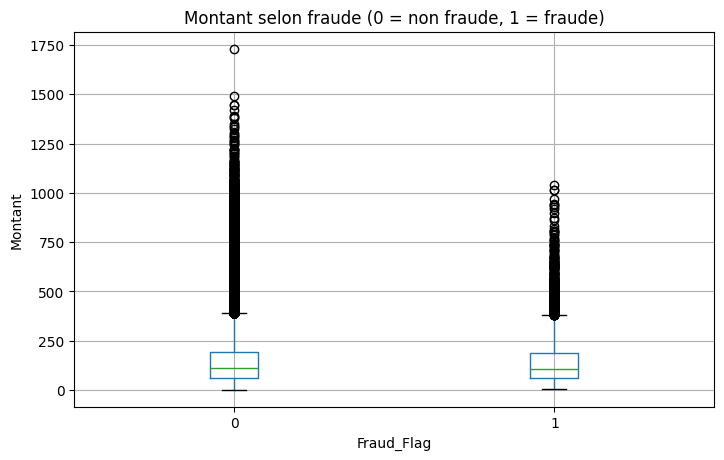

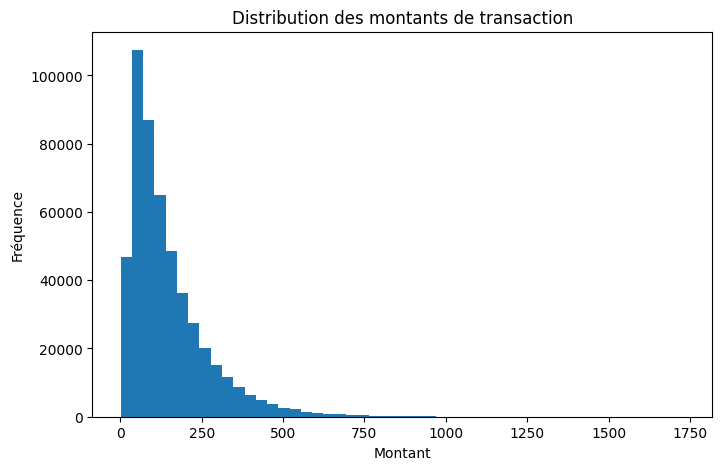

In [36]:
import matplotlib.pyplot as plt

data.boxplot(column="Amount", by="Fraud_Flag", figsize=(8,5))
plt.title("Montant selon fraude (0 = non fraude, 1 = fraude)")
plt.suptitle("")
plt.ylabel("Montant")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(data["Amount"], bins=50)
plt.title("Distribution des montants de transaction")
plt.xlabel("Montant")
plt.ylabel("Fréquence")
plt.show()

##### Distance_from_home:
  les valeurs tres elevees peuvent etre des cas paticuliers si le client est en voyage dans un autre pays ou alors cest valeurs correspende a une utilisation fraudileuse dans un autre pays ou dans un domicile different que le proprietaire de la carte. Donc, on decide de conservees ces valeurs car une grande distance est un signal cle de fraude.

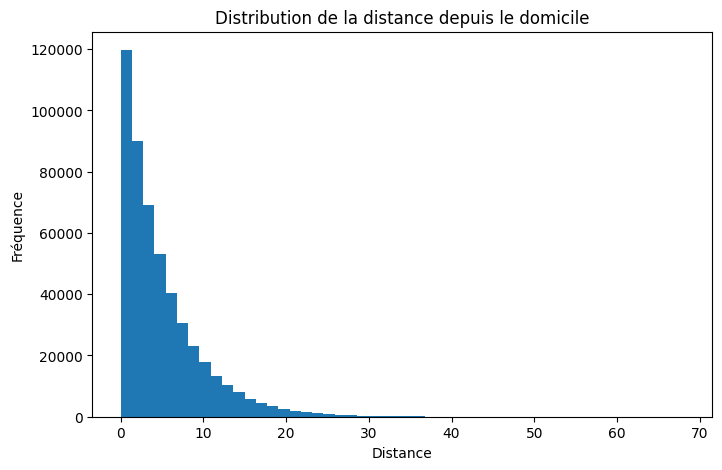

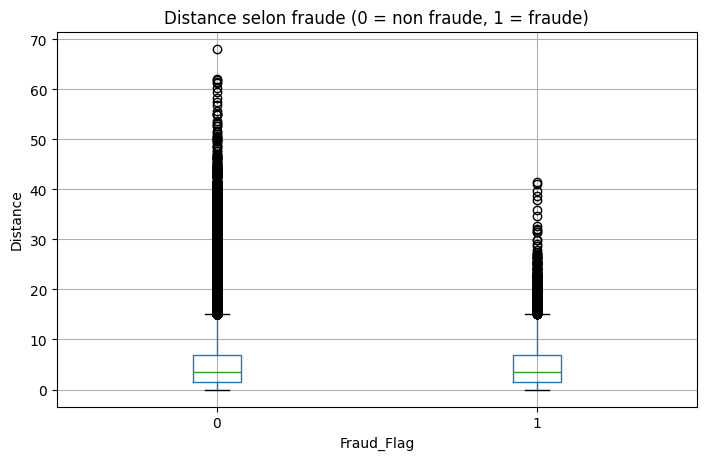

In [37]:
plt.figure(figsize=(8,5))
plt.hist(data["Distance_From_Home"], bins=50)
plt.title("Distribution de la distance depuis le domicile")
plt.xlabel("Distance")
plt.ylabel("Fréquence")
plt.show()

data.boxplot(column="Distance_From_Home", by="Fraud_Flag", figsize=(8,5))
plt.title("Distance selon fraude (0 = non fraude, 1 = fraude)")
plt.suptitle("")
plt.ylabel("Distance")
plt.show()


##### Hour_of_day:
On remarque aucune valeurs aberrantes sup , on ne change rien.

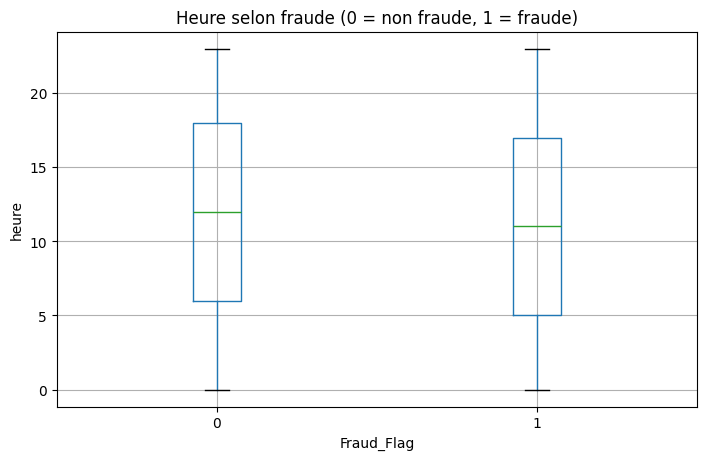

In [38]:


data.boxplot(column="Hour_of_Day", by="Fraud_Flag", figsize=(8,5))
plt.title("Heure selon fraude (0 = non fraude, 1 = fraude)")
plt.suptitle("")
plt.ylabel("heure")
plt.show()

##### Maintenant pour les valeurs categorielles:

##### Merchant_ID:
 On remarque que tous les id sont de meme longeur (=4) donc on a aucun id aberrant.


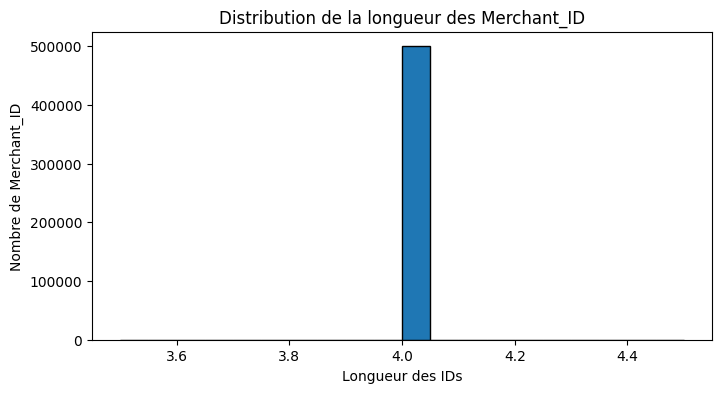

In [39]:
data['Merchant_ID_length'] = data['Merchant_ID'].astype(str).apply(len)

# Créer l'histogramme avec matplotlib
plt.figure(figsize=(8,4))
plt.hist(data['Merchant_ID_length'], bins=20, edgecolor='black')
plt.title('Distribution de la longueur des Merchant_ID')
plt.xlabel('Longueur des IDs')
plt.ylabel('Nombre de Merchant_ID')
plt.show()

##### Merchant_Category:
on remarque aucune valeur aberrante. Encore une fois, distribution très équilibréee.

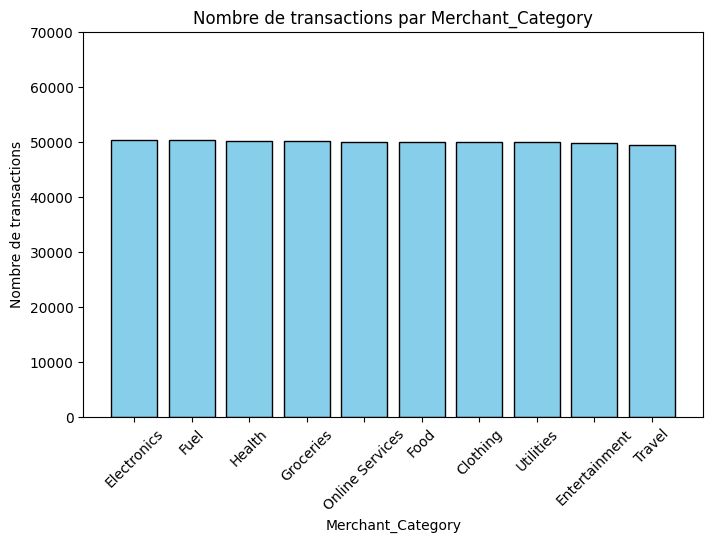

In [40]:
#compter le nombre de transactions par Merchant_Category
card_counts = data['Merchant_Category'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(card_counts.index, card_counts.values, color='skyblue', edgecolor='black')
plt.title("Nombre de transactions par Merchant_Category")
plt.xlabel("Merchant_Category")
plt.ylabel("Nombre de transactions")
plt.xticks(rotation=45)  
plt.ylim(0, 70000) 
plt.show()

##### Card_Type:
 Aucune valeur aberrante ou cas particulier. Les catégories sont parfaitement équilibrées — il n’y a pas de type de carte rare ou suspect

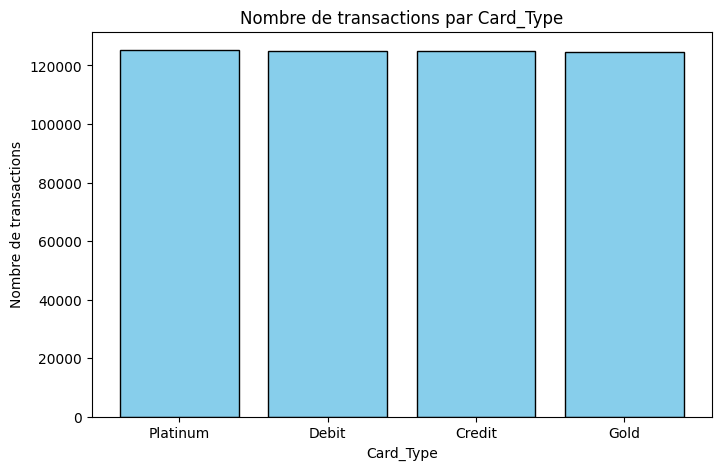

In [41]:
#compter le nombre de transactions par Card_Type
card_counts = data['Card_Type'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(card_counts.index, card_counts.values, color='skyblue', edgecolor='black')
plt.title("Nombre de transactions par Card_Type")
plt.xlabel("Card_Type")
plt.ylabel("Nombre de transactions")
plt.show()



##### Transaction_Type:
on voit que les type de transactions sont seulement Online, ATM et Pos on a aucune valeur abberantes ou de cas particulier.

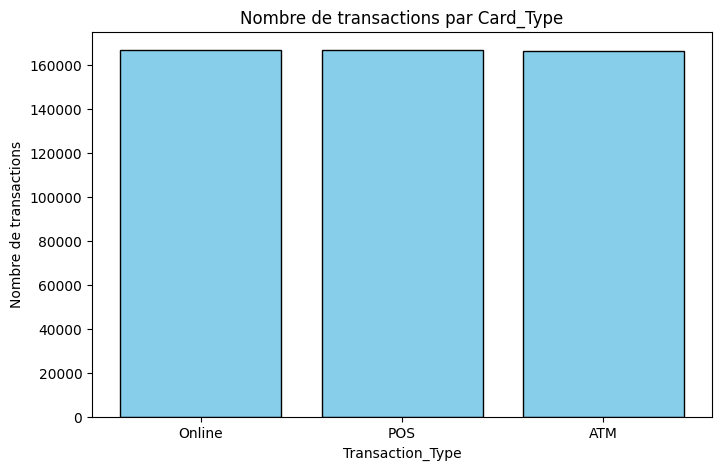

In [42]:
#compter le nombre de transactions par Transaction_Type
card_counts = data['Transaction_Type'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(card_counts.index, card_counts.values, color='skyblue', edgecolor='black')
plt.title("Nombre de transactions par Card_Type")
plt.xlabel("Transaction_Type")
plt.ylabel("Nombre de transactions")
plt.show()

##### Country: 
Les country cité dans notre dataset sont seulement UK,CANADA, FRANCE,AUSTRALIA, GERMANY, INDIA, SINGAPORE et USA on a donc aucune valeur incorrect d'un pays innexistant ou autre. Cependant, on remarque aucune difference  de taux de fraude dans les pays d'europe que les pays d'Asie et Amerique. Alors, il serait plus avantageux de faire l'etude dans les pays d'europe uniquement, c'est a dire on suprrime les transactions faites en USA,Canada,Inde,Singuapour,Australie,Canada . Cela va reduire notre dataset a 375020 lignes.

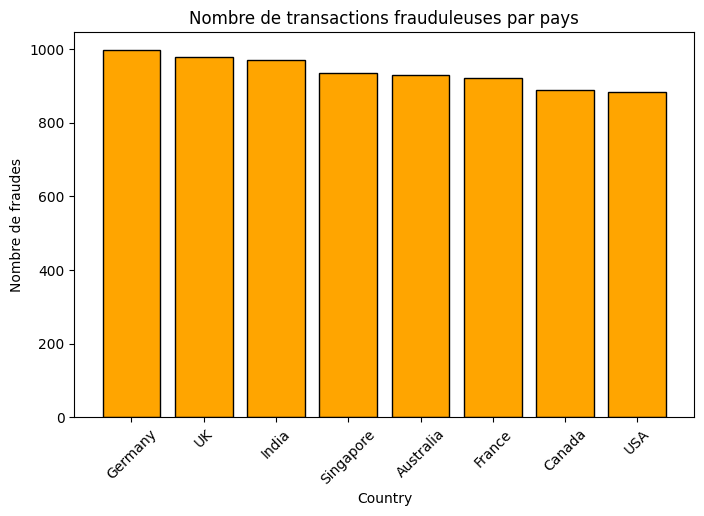

['Germany' 'Australia' 'India' 'UK' 'France' 'Singapore']


In [43]:
	
# Filtrer uniquement les transactions frauduleuses
fraud_transactions = data[data['Fraud_Flag'] == 1]
# Compter le nombre de fraudes par pays
fraud_counts_by_country = fraud_transactions['Country'].value_counts()
# Bar chart 
plt.figure(figsize=(8,5))
plt.bar(fraud_counts_by_country.index, fraud_counts_by_country.values, color='orange', edgecolor='black')
plt.title("Nombre de transactions frauduleuses par pays")
plt.xlabel("Country")
plt.ylabel("Nombre de fraudes")
plt.xticks(rotation=45)
plt.show()

countries_to_remove = ['USA', 'Canada', 'Inde', 'Singapour', 'Australie']
# Garder uniquement les transactions dont le pays n'est pas dans la liste
data = data[~data['Country'].isin(countries_to_remove)]

# Vérifier
print(data['Country'].unique())

In [44]:
print(data.shape)

(375020, 17)


##### Device_Type: 
Aucune valeur aberrante. Encore une fois, distribution très équilibrée.

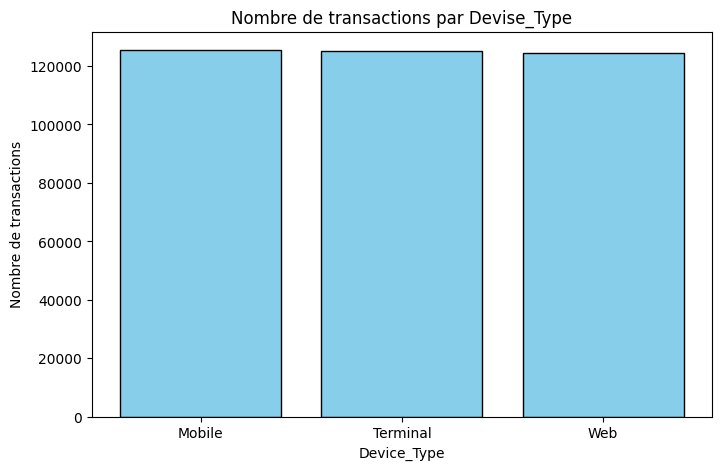

In [45]:
#compter le nombre de transactions par Device_Type
card_counts = data['Device_Type'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(card_counts.index, card_counts.values, color='skyblue', edgecolor='black')
plt.title("Nombre de transactions par Devise_Type")
plt.xlabel("Device_Type")
plt.ylabel("Nombre de transactions")
plt.show()


### 3.4 Encodage et mise à l’échelle des variables
Certaines variables doivent être converties en numériques avant d’être utilisées dans un modèle.


Questions :
-	Quelles colonnes ont été encodées ?
-	Quelle méthode avez-vous utilisée ?
-	Pourquoi est-il important de normaliser ou standardiser les données avant l’entraînement des modèles ?


##### One-Hot Enconding:
les colonnes qui ont été encodées (de categorie texte) sont :  
Card_Type  
Transaction_Type  
Country  
Device_Type  

Cette méthode consiste à transformer chaque catégorie en une variable binaire.  
Elle est adaptée aux variables qualitatives nominales qui ne peuvent pas etre utilisées directement par un modèle de machine learning, car elle n’introduit pas de relation d’ordre artificielle entre les catégories. 

In [46]:
data = pd.get_dummies(
    data,
    columns=[
        "Merchant_Category",
        "Card_Type",
        "Transaction_Type",
        "Country",
        "Device_Type",
        "Merchant_Category",
    ],
    drop_first=True
)


##### Normalisation:

les colonnes consérnees;
Amount, Distance_From_Home, Hour_Of_Day

-La normalisation ou la standardisation des données est importante car certains modèles de machine learning sont sensibles à l’échelle des variables.  Sans mise à l’échelle, les variables ayant de grandes valeurs numériques peuvent influencer excessivement le modèle par rapport aux autres. Par exemple amount(milliers) et hour_of_day(entre 0-23) sans standardisation, le modèle donnerait beaucoup plus de poids à Amount, même si ce n’est pas forcément la variable la plus importante.


In [47]:
from sklearn.preprocessing import StandardScaler

# Colonnes numériques à standardiser
num_cols = ["Amount", "Distance_From_Home", "Hour_of_Day"]

scaler = StandardScaler()

# Standardiser uniquement les colonnes numériques
data[num_cols] = scaler.fit_transform(data[num_cols])

# Vérification rapide
print(data[num_cols].head())

     Amount  Distance_From_Home  Hour_of_Day
0 -0.526789           -0.677520    -0.075201
1 -0.769323            2.151504     1.226408
4  0.271160           -0.735459     1.226408
5  2.065285            0.209547     0.937162
6 -0.644171           -0.415796     0.792538


##### Transaction_Date:
Date/heure d’une transaction ne pas etre utiliser telle quelle, on doit les transformer en caractéristiques numériques utiles.

In [48]:
data['Transaction_Date'] = pd.to_datetime(data['Transaction_Date'], errors='coerce')
data["Transaction_DayOfWeek"] = data["Transaction_Date"].dt.dayofweek
data["Transaction_Hour"] = data["Transaction_Date"].dt.hour
data["Transaction_Month"] = data["Transaction_Date"].dt.month
data.drop("Transaction_Date", axis=1, inplace=True)
data.dtypes

Transaction_ID                         int64
Customer_ID                            int64
Amount                               float64
Merchant_ID                            int64
Is_International                       int64
Is_Chip                                int64
Is_Pin_Used                            int64
Distance_From_Home                   float64
Hour_of_Day                          float64
Fraud_Flag                             int64
Merchant_ID_length                     int64
Merchant_Category_Electronics           bool
Merchant_Category_Entertainment         bool
Merchant_Category_Food                  bool
Merchant_Category_Fuel                  bool
Merchant_Category_Groceries             bool
Merchant_Category_Health                bool
Merchant_Category_Online Services       bool
Merchant_Category_Travel                bool
Merchant_Category_Utilities             bool
Card_Type_Debit                         bool
Card_Type_Gold                          bool
Card_Type_

##### Valeur binaire:
Is_International, Is_Chip, Is_Pin_Used;
Ce sont des variables binaires (0 ou 1), pas besoin de standardiser. Déjà utilisables directement dans les modèles ML

##### Les ID's
ici chaque transaction est unique donc on a pas de valeur informative pour la fraude. On decide alors de les ignorer l'encodage n'est pas necessaire


##### CONCLUSION:
Notre dataset etait deja nettoyer sans valeurs manques ni valeurs aberrante nécéssitant une suppréssion de valeur. Sauf pour la valeur Country, on a decidéde garder seulement les pays d'europe car la conservation des autres pays n'aurais aucun impacte interessant pour notre etude. Apres cela on a encoder nos valeur avec du one-hot encoding et de la normalisaion.

### Partie 4 – Analyse exploratoire et visualisations
Réalisez une première exploration visuelle pour mieux comprendre les relations entre les variables.
Questions :
-	Quelles relations ou corrélations observez-vous ?
-	Quelles variables semblent influencer la variable cible ?
-	Quelles hypothèses pouvez-vous formuler ?
-	Quelles tendances ou patterns remarquez-vous dans les graphiques ?


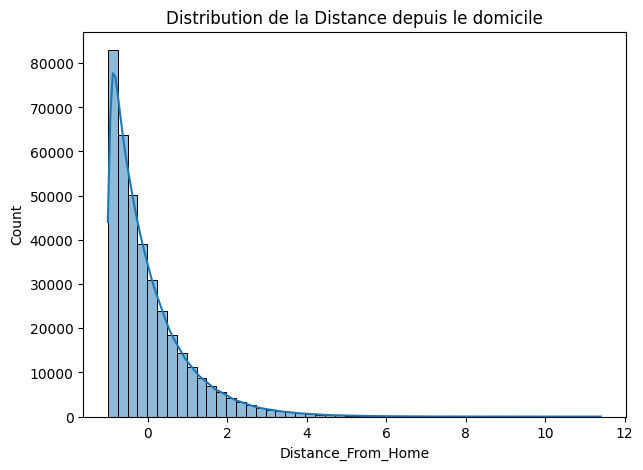

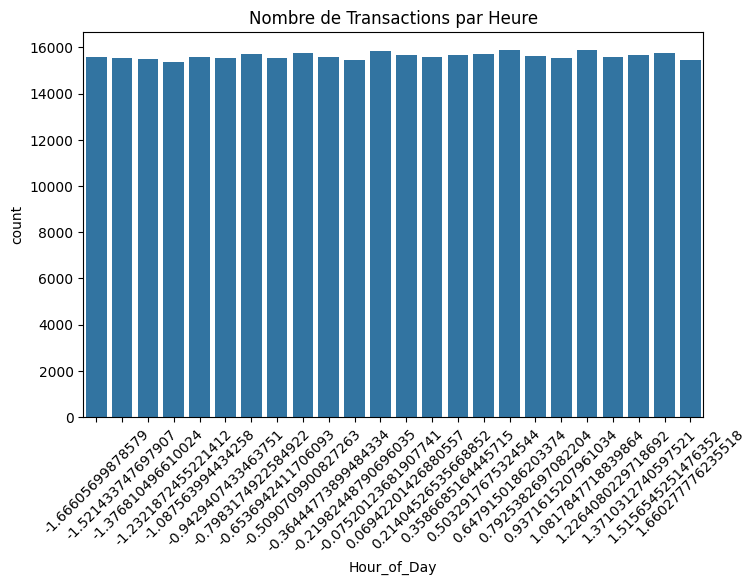

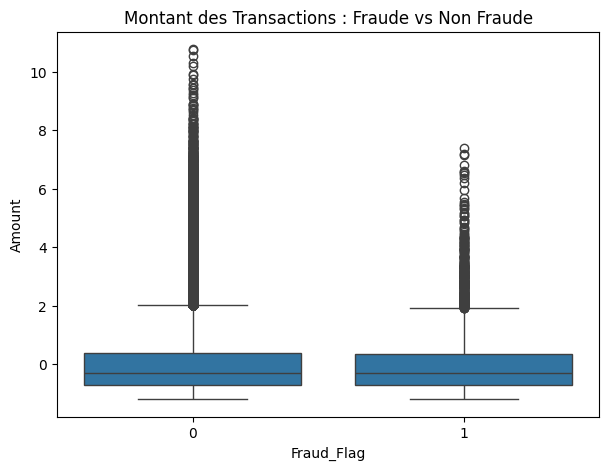

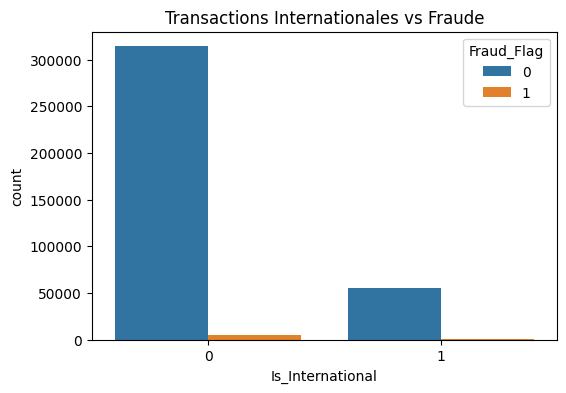

In [49]:
import seaborn as sns
#distance depuis le domicile
plt.figure(figsize=(7,5))
sns.histplot(data["Distance_From_Home"], bins=50, kde=True)
plt.title("Distribution de la Distance depuis le domicile")
plt.show()

#repartion des transaction par heure 
plt.figure(figsize=(8,5))
sns.countplot(x="Hour_of_Day", data=data)
plt.title("Nombre de Transactions par Heure")
plt.xticks(rotation=45)
plt.show()

#comparaison fraude vs non frande (montant)
plt.figure(figsize=(7,5))
sns.boxplot(x="Fraud_Flag", y="Amount", data=data)
plt.title("Montant des Transactions : Fraude vs Non Fraude")
plt.show()

#variable internationale 
plt.figure(figsize=(6,4))
sns.countplot(x="Is_International", hue="Fraud_Flag", data=data)
plt.title("Transactions Internationales vs Fraude")
plt.show()

1-Distribution des montants des transactiosn: Cela montre une hétérogénéité importante des comportements financiers :
Certains clients effectuent principalement de petites transactions.
Alors que d’autres réalisent occasionnellement des transactions très élevées.

2-Nombre de transactions par heure: Dans le graphe la distribution est quasi uniforme sur les heures. Donc Le comportement horaire ne semble pas être un facteur fortement discriminant à lui seul.
Cela suggère que l’heure ne crée pas de séparation naturelle forte.

3-Montant : Fraude vs Non Fraude (Boxplot): On remarque que les distributions sont tres proches. Il n’y a pas de séparation nette entre fraude et non fraude uniquement via le montant.
Cela confirme que :
La fraude ne dépend pas d’un seuil simple de montant.

4-Transactions internationales vs Fraude: On observe pas de différence proportionnelle massive visible. Donc Le caractère international n’est pas un facteur discriminant dominant.
Il peut contribuer légèrement au risque,
mais il ne permet pas à lui seul d’isoler un profil spécifique.

Matrice de corrélation:

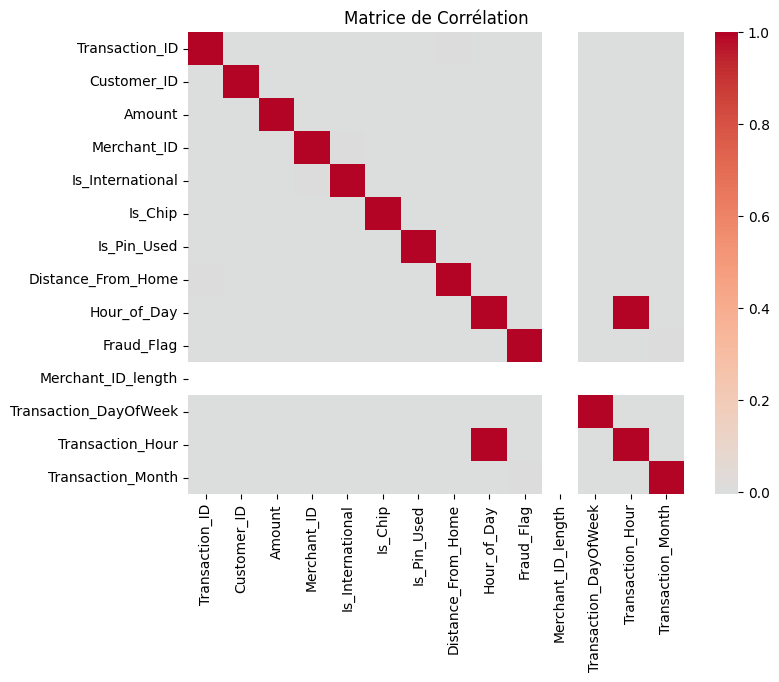

In [50]:
plt.figure(figsize=(8,6))
corr = data.select_dtypes(include="number").corr()

sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matrice de Corrélation")
plt.show()

5-Matrice de corrélation: On observe directement une abssence de correlation forte elles sont majoriterement faibles ou proches de 0. Cela indique que:

-Les variables transactionnelles sont relativement indépendantes.

-Il n’existe pas de relation linéaire simple permettant d’expliquer le comportement des clients.

-La fraude ne dépend pas d’une seule variable dominante.

Cela renforce l’idée que le comportement transactionnel est multidimensionnel et qu’une approche basée sur la combinaison des variables est pertinente.

#### Les hypothèses 
À partir de l’analyse exploratoire, plusieurs hypothèses peuvent être formulées.
| Hypothèse | Formulation                                                                                                                                         |
| --------- | --------------------------------------------------------------------------------------------------------------------------------------------------- |
| H1        | Les clients peuvent être segmentés selon leur niveau et leur variabilité de dépenses.                                                               |
| H2        | Le comportement transactionnel repose sur plusieurs dimensions indépendantes (montant, fréquence, distance), et non sur un facteur unique dominant. |
| H3        | La fraude ne correspond pas à un profil comportemental clairement distinct à partir des variables agrégées disponibles.                             |


#### tendances ou patterns

Les visualisations mettent en évidence plusieurs tendances/structure répétitive/régularité notables.

1-Asymétrie des montants (pattern de distribution)
Pattern observé :
Comportement de dépense hétérogène avec quelques transactions extrêmes.

2-Absence de pic horaire marqué
Pattern observé :
Le comportement horaire est stable et peu discriminant.

3-Similarité fraude / non-fraude
Pattern observé :
La fraude ne présente pas un comportement radicalement différent en termes de montant.

4-Transactions internationales
Pattern observé :
Le caractère international n’est pas un facteur dominant.

5-Faible corrélation globale
Pattern observé :
Le comportement client est multidimensionnel.

# RAPPORT PARTIE 2 – IMPLÉMENTATION ET EVALUATION DES MODÈLES

## Partie 5 – Implémentation de modèles de Machine Learning

### 5.1 Définition de la tâche d’apprentissage
Questions à traiter :
-   Le projet relève-t-il d’un apprentissage supervisé ou non supervisé.
-	Quelle est la variable cible.
-	Quel est le type de modèle retenu (classification, régression, clustering).
-	Quelle métrique d’évaluation est la plus adaptée à la problématique.
Réponse (à rédiger et justifier avec arguments) :


##### Type d’apprentissage

Dans ce projet, nous avons choisi d’aborder la problématique sous l’angle de la détection d’anomalies dans les transactions bancaires.
Il s’agit d’un apprentissage non supervisé, car l’objectif principal n’est pas de prédire directement la variable Fraud_Flag, mais de découvrir des groupes naturels afin de faire une analyse exploratoire avancée.

##### Variable cible
Il n’y a pas de variable cible supervisée.

##### Type de modèle retenu

Etant donne notre objectif qui est de segmenter les clients selon leurs comportement transactionnels, on decide alors m'utiliser K-Means pour faire du Clustering.
K-Means est simple et robuste, interpretable, adabte aux donnees numeriques et tres utilise en segmentation client.
##### Métrique retenue

La metique retenue pour le clustering est l'Inertie qui mesure la somme des distances entre les points d'un cluster et leur centre (centroide). Plus l’inertie est faible → plus les clusters sont compacts. On utilise aussi Score de Silhouette qui mesure a quel point un point est proche de son cluster compare aux etres clusters.

### 5.2 Séparation des données

Dans le cadre de cette étude basée sur un apprentissage non supervisé (clustering), une séparation train/test n’a pas été jugée indispensable, car l’objectif n’est pas de prédire une variable cible mais d’identifier des structures naturelles au sein des données. Le modèle KMeans a donc été entraîné sur l’ensemble des observations afin de maximiser la stabilité des regroupements obtenus.

### 5.3 Feature Engineering

##### 1-Création de client_data: data set comportemental
La création de client_data permet de transformer les données transactionnelles brutes en indicateurs comportementaux agrégés au niveau client, afin de rendre la segmentation cohérente avec l’objectif de l’étude.

In [51]:
client_data = data.groupby("Customer_ID").agg(
    Amount_mean=("Amount", "mean"),
    Amount_std=("Amount", "std"),
    Amount_max=("Amount", "max"),
    Amount_count=("Amount", "count"),
    Distance_mean=("Distance_From_Home", "mean"),
    Distance_std=("Distance_From_Home", "std"),
    International_rate=("Is_International", "mean"),
    Pin_rate=("Is_Pin_Used", "mean"),
    Night_rate=("Hour_of_Day", lambda x: ((x < 6) | (x > 22)).mean())
).reset_index()
client_data = client_data.fillna(0)


Le clustering doit regrouper : des profils clients pas des transactions individuelles. C'est pour cela qu'on cree un nouveau dataset agrege par client

### 5.4 Implémentation des modèles

##### Methode du coude

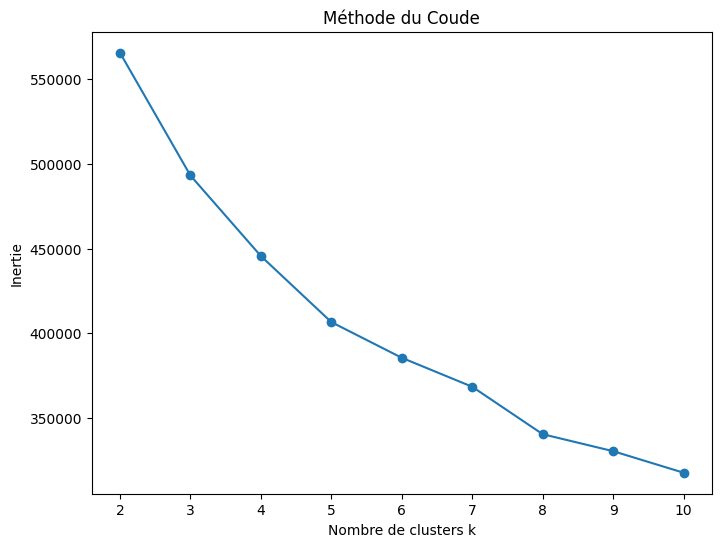

In [52]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

#Préparation des données
X = client_data.drop(["Customer_ID"],axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Calcul de l'inertie pour différents k
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

#Graphique du coude
plt.figure(figsize=(8,6))
plt.plot(K_range, inertia, marker='o')
plt.title("Méthode du Coude")
plt.xlabel("Nombre de clusters k")
plt.ylabel("Inertie")
plt.show()

Bien que plusieurs valeurs de k aient été testées, l’analyse visuelle (projection PCA) a montré qu’un nombre de 5 clusters permettait d’identifier des profils distincts tout en conservant une bonne interprétabilité.

In [53]:
kmeans = KMeans(n_clusters=5, random_state=42)
client_data["Cluster"] = kmeans.fit_predict(X_scaled)
cluster_summary = client_data.groupby("Cluster").mean()
print(cluster_summary)

          Customer_ID  Amount_mean  Amount_std  Amount_max  Amount_count  \
Cluster                                                                    
0        55016.719228    -0.269880    0.384667    0.115494      2.746220   
1        54971.996629    -0.034794    0.821881    1.266065      6.138507   
2        55232.216704    -0.205625    0.522552    0.362291      3.287919   
3        54661.464051     0.808104    1.686288    3.094100      4.282590   
4        55149.588659    -0.128833    0.645371    0.648111      3.874723   

         Distance_mean  Distance_std  International_rate  Pin_rate  Night_rate  
Cluster                                                                         
0            -0.238693      0.406122            0.007740  0.193819         1.0  
1            -0.079019      0.786110            0.130473  0.201975         1.0  
2            -0.169034      0.567744            0.460535  0.195515         1.0  
3            -0.063231      0.744563            0.137089  0.20

##### Visualisation sans PCA a 2D seulement:

Silhouette Score : 0.16349755648633396


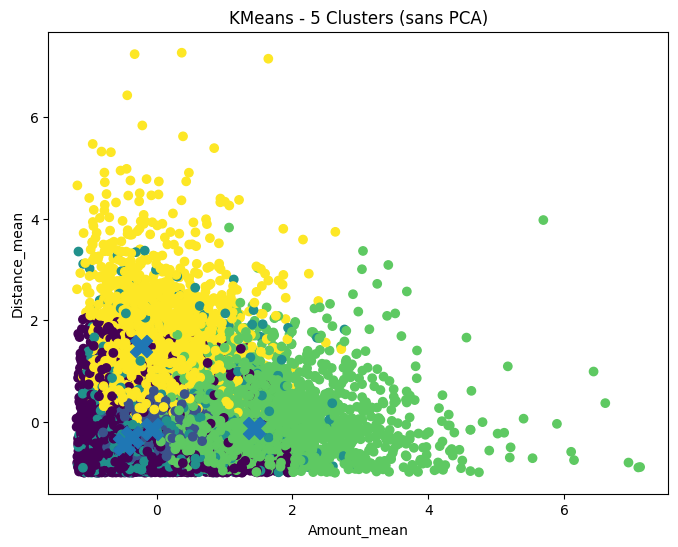

In [59]:
# Choisir deux variables pour visualiser
x = client_data["Amount_mean"]
y = client_data["Distance_mean"]

score = silhouette_score(X_scaled, client_data["Cluster"])
print("Silhouette Score :", score)

plt.figure(figsize=(8,6))

plt.scatter(
    x,
    y,
    c=client_data["Cluster"]
)

# Ajouter les centroïdes (dans l’espace réel)
centroids = kmeans.cluster_centers_

plt.scatter(
    centroids[:, X.columns.get_loc("Amount_mean")],
    centroids[:, X.columns.get_loc("Distance_mean")],
    marker='X',
    s=250
)

plt.xlabel("Amount_mean")
plt.ylabel("Distance_mean")
plt.title("KMeans - 5 Clusters (sans PCA)")
plt.show()

##### Visualisation par PCA
Une réduction de dimension par Analyse en Composantes Principales (PCA) a été réalisée afin de projeter les données dans un espace bidimensionnel.

Silhouette Score : 0.16349755648633396


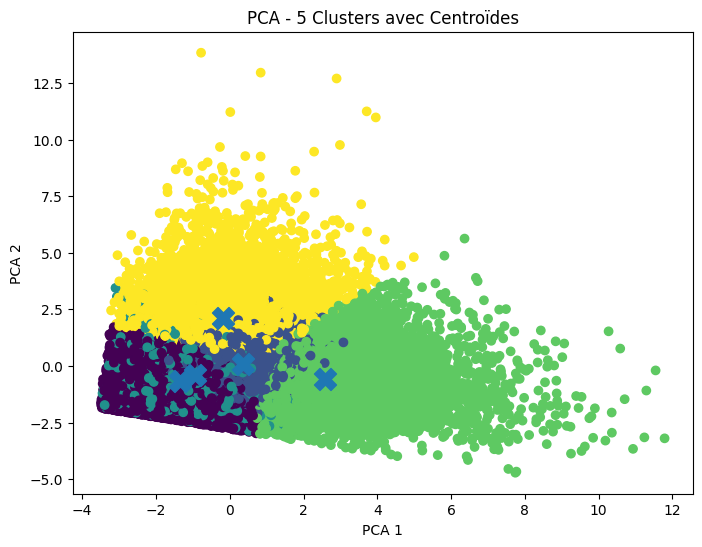

In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

X = client_data.drop(columns=["Customer_ID", "Cluster"])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

score = silhouette_score(X_scaled, client_data["Cluster"])
print("Silhouette Score :", score)

centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=client_data["Cluster"])
plt.scatter(
    centroids_pca[:,0],
    centroids_pca[:,1],
    marker='X',
    s=250
)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA - 5 Clusters avec Centroïdes")
plt.show()


La visualisation montre :

Un cluster clairement séparé à droite (clients très actifs)

Un cluster distinct en haut (clients internationaux)

Un cluster compact représentant les petits dépensiers locaux

Des centroïdes bien positionnés au cœur de chaque groupe

Bien que certains chevauchements existent (réduction de 9 dimensions vers 2), la structure globale confirme la pertinence de la segmentation.

Profile
Clients actifs                 26107
Petits dépensiers locaux       22488
Gros dépensiers irréguliers    13992
Clients internationaux         13410
Clients mobiles                12644
Name: count, dtype: int64


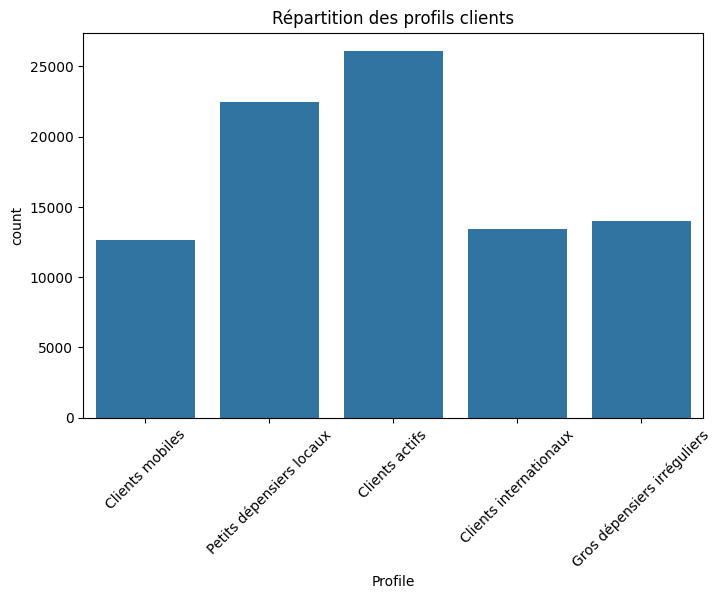

In [57]:
profile_names = {
    0: "Petits dépensiers locaux",
    1: "Clients actifs",
    2: "Clients internationaux",
    3: "Gros dépensiers irréguliers",
    4: "Clients mobiles"
}

client_data["Profile"] = client_data["Cluster"].map(profile_names)
print(client_data["Profile"].value_counts())
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(x="Profile", data=client_data)
plt.xticks(rotation=45)
plt.title("Répartition des profils clients")
plt.show()

##### Interpretation des profils clients:
La segmentation a permis d’identifier quatre profils principaux :

Gros dépensiers irréguliers(Profil à comportement financier intense et irrégulier.)

Clients internationaux (Clients exposés aux paiements transfrontaliers.)

Petits dépensiers locaux (Profil stable et peu risqué comportementalement.)

Clients actifs (Clients réguliers avec forte activité.)

Clients mobiles (Clients géographiquement mobiles.)

## Partie 6 — Évaluation des modèles

### 6.2 Résultats des modèles
Présenter les résultats sous forme de tableau comparatif.  
| **Modèle**  | **Paramètres** | **Métrique principale**  | **Autres métriques** | **Temps d’entraînement**|
|------------ |----------------|--------------------------|----------------------|-------------------------|
| KMeans      |            k=5 |  Silouhette=0.16        | on ne peux pas projeter 9 var en 2D     | 2min51                  |   
| KMeans+PCA  | k=5           | Silouhette=0.16          |Visualisation claire  |  2min14                 |
|Agglomerative|k=5           |--------------------------|Structure Hierarchique|O(n²) pas adapte au gros dataset|

  


##### Analyse complémentaire : Répartition des fraudes par segment:
Bien que le clustering soit une méthode non supervisée, une analyse post-segmentation a été réalisée afin d’évaluer la répartition des transactions frauduleuses au sein des différents segments identifiés.


Cluster
0    0.015771
1    0.015325
2    0.014765
3    0.015921
4    0.014166
Name: Fraud_Flag, dtype: float64
Cluster
0     974
1    2456
2     651
3     954
4     694
Name: Fraud_Flag, dtype: int64


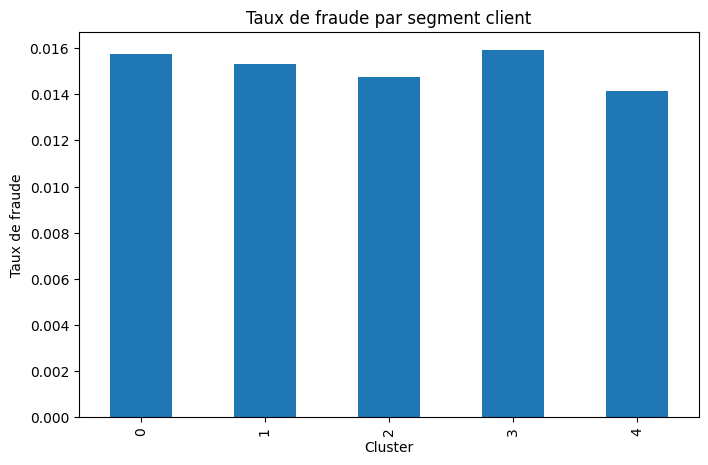

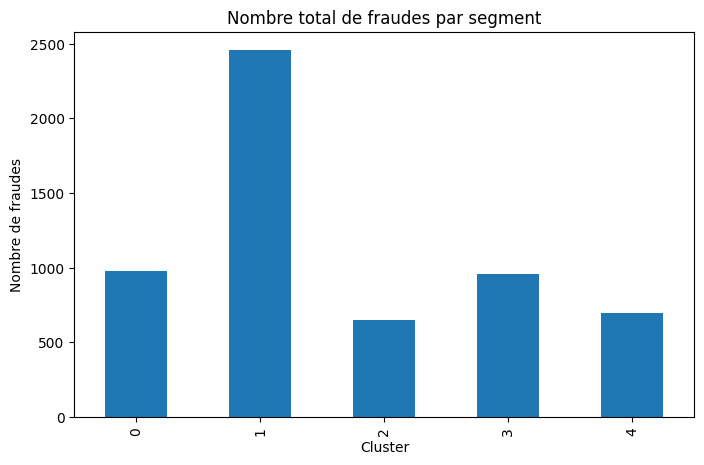

In [56]:
data_with_cluster = data.merge(
    client_data[["Customer_ID", "Cluster"]],
    on="Customer_ID",
    how="left"
)
fraud_by_cluster = data_with_cluster.groupby("Cluster")["Fraud_Flag"].mean()
print(fraud_by_cluster)
fraud_count = data_with_cluster.groupby("Cluster")["Fraud_Flag"].sum()
print(fraud_count)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
fraud_by_cluster.plot(kind="bar")
plt.title("Taux de fraude par segment client")
plt.ylabel("Taux de fraude")
plt.xlabel("Cluster")
plt.show()
plt.figure(figsize=(8,5))
fraud_count.plot(kind="bar")
plt.title("Nombre total de fraudes par segment")
plt.ylabel("Nombre de fraudes")
plt.xlabel("Cluster")
plt.show()

##### Resultat de l'analyse:
L’analyse de la répartition des transactions frauduleuses montre que les taux de fraude varient légèrement entre les segments identifiés, allant de 1.41 % à 1.59 %.

Bien que le cluster 3 (Clients Actifs) présente le taux le plus élevé, l’écart observé demeure faible.

Cela indique que la fraude ne correspond pas à un profil comportemental fortement distinct au sein des variables étudiées. La segmentation permet d’identifier des profils clients cohérents, mais ne révèle pas de groupe présentant un risque significativement supérieur.

### 6.3 Interprétation des résultats
Questions à aborder :
-	Les performances sont-elles cohérentes avec les hypothèses initiales.  
-	Des biais apparaissent-ils dans certaines classes.  
-	Certaines classes sont-elles plus difficiles à prédire.  
-	Les variables importantes sont-elles pertinentes et cohérentes avec la problématique.  
Réponse (à rédiger, justifier avec graphiques ou coefficients) :


L’objectif initial était d’identifier des profils comportementaux distincts parmi les clients sur la base de leurs habitudes transactionnelles (montant moyen, fréquence, distance, variabilité). Cependant, le score de silhouette obtenu (≈ 0.16) indique une séparation modérée entre les clusters.
Cela suggère que les comportements clients sont relativement homogènes, ce qui est cohérent avec la nature des données transactionnelles bancaires où les comportements extrêmes restent minoritaires.
Ainsi, les performances sont cohérentes avec l’hypothèse d’une segmentation possible mais faiblement marquée.

Contrairement à un problème de classification supervisée, le clustering ne comporte pas de notion de classe cible prédéfinie.
Étant donné qu’il s’agit d’un apprentissage non supervisé, il n’y a pas de “prédiction” de classes au sens classique.
Cependant, l’analyse des taux de fraude par cluster indique que :
Les clients actifs présentent parfois une proportion légèrement plus élevée de transactions frauduleuses contrairement aux clients gros dépenciers iréguliers.
Néanmoins, ces différences restent modérées.
Cela suggère que la fraude ne constitue pas un comportement radicalement distinct, mais plutôt une variation subtile au sein de profils existants.

Les variables les plus discriminantes dans la segmentation sont :
Amount_mean, Amount_std, Amount_count, Distance_From_Home_mean.
Ces variables sont cohérentes avec la problématique car elles décrivent :
L’intensité des dépenses, La régularité du comportement, La mobilité géographique. 
En revanche, les variables :
Is_International_mean,Is_Chip_mean, Is_Pin_Used_mean présentent des moyennes très proches entre clusters, ce qui limite leur pouvoir discriminant.

##### Conclusion :
La segmentation révèle une structure comportementale cohérente mais peu fortement séparée.
Cela peut s’expliquer par :

Une homogénéité naturelle des comportements bancaires.

L’absence de variables séquentielles (historique temporel avancé).

L’absence de variables comportementales fines (pattern dynamique).

Malgré un score de silhouette modéré, les clusters identifiés présentent une cohérence métier et permettent d’identifier des segments exploitables.

### 6.4 Visualisations d’évaluation  

Plusieurs visualisations ont été utilisées afin d’évaluer la qualité du clustering :

La méthode du coude a permis de déterminer le nombre optimal de clusters.

La projection PCA a facilité l’analyse visuelle de la séparation des groupes.

L’analyse des taux de fraude par cluster a permis d’évaluer la pertinence métier de la segmentation.

Les graphiques montrent une séparation modérée entre les segments, cohérente avec le score de silhouette obtenu (≈ 0.16). La fraude apparaît répartie de manière relativement homogène, suggérant qu’elle ne correspond pas à un profil comportemental distinct dans l’espace des variables étudiées.

## Partie 7 – Discussion critique
Cette partie vise à analyser les résultats de manière scientifique. Elle ne doit pas être rédigée comme une conclusion narrative ou générale.


## 7.1 Limites des modèles

Le modèle présente certaines limites. Tout d’abord, le choix du nombre de clusters reste partiellement subjectif, même s’il est appuyé par la méthode du coude et le Silhouette Score. Le score obtenu étant modéré, cela indique que la séparation entre les groupes n’est pas très marquée.

De plus, les variables disponibles sont principalement transactionnelles et agrégées, ce qui ne permet pas de capturer des comportements plus complexes ou dynamiques comme par exemple on ne peut pas determiner une frequence anormale de transactions sur une courte periode et dans des lieux differents. Certaines informations non disponibles pourraient mieux expliquer les différences entre clients.

Enfin, l’algorithme KMeans suppose des clusters de forme relativement sphérique et de taille comparable, ce qui peut ne pas refléter parfaitement la structure réelle des données.

## 7.2 Pistes d’amélioration
Plusieurs pistes d’amélioration peuvent être envisagées afin d’enrichir l’analyse. 

Tout d’abord, un travail plus approfondi de feature engineering pourrait être réalisé, notamment en intégrant des variables dynamiques telles que la fréquence des transactions sur une courte période, l’évolution des dépenses dans le temps ou des indicateurs de variation comportementale. L’ajout de données complémentaires (profil socio-démographique, historique long terme) permettrait également d’améliorer la représentativité des profils clients.

Par ailleurs, d’autres algorithmes de clustering plus avancés ou adaptés aux structures complexes (DBSCAN, Gaussian Mixture Models) pourraient être testés afin de comparer la qualité de segmentation. Une approche alternative consisterait également à appliquer des méthodes supervisées si l’objectif évolue vers la prédiction du risque
